# IDENTIFICACIÓN NADADORES EN PISCINA - EXPLORACIÓN INICIAL DE COLORES PARA MÁSCARA DEL FONDO

Juan David Hurtado Molano

Laura Sofía Salamanca Barrera

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Vista superior

En la vista superior de la piscina se encuentran un panorama completo de la piscina, los carriles bien divididos y los nadadores no se sobrelapan en la imagen.

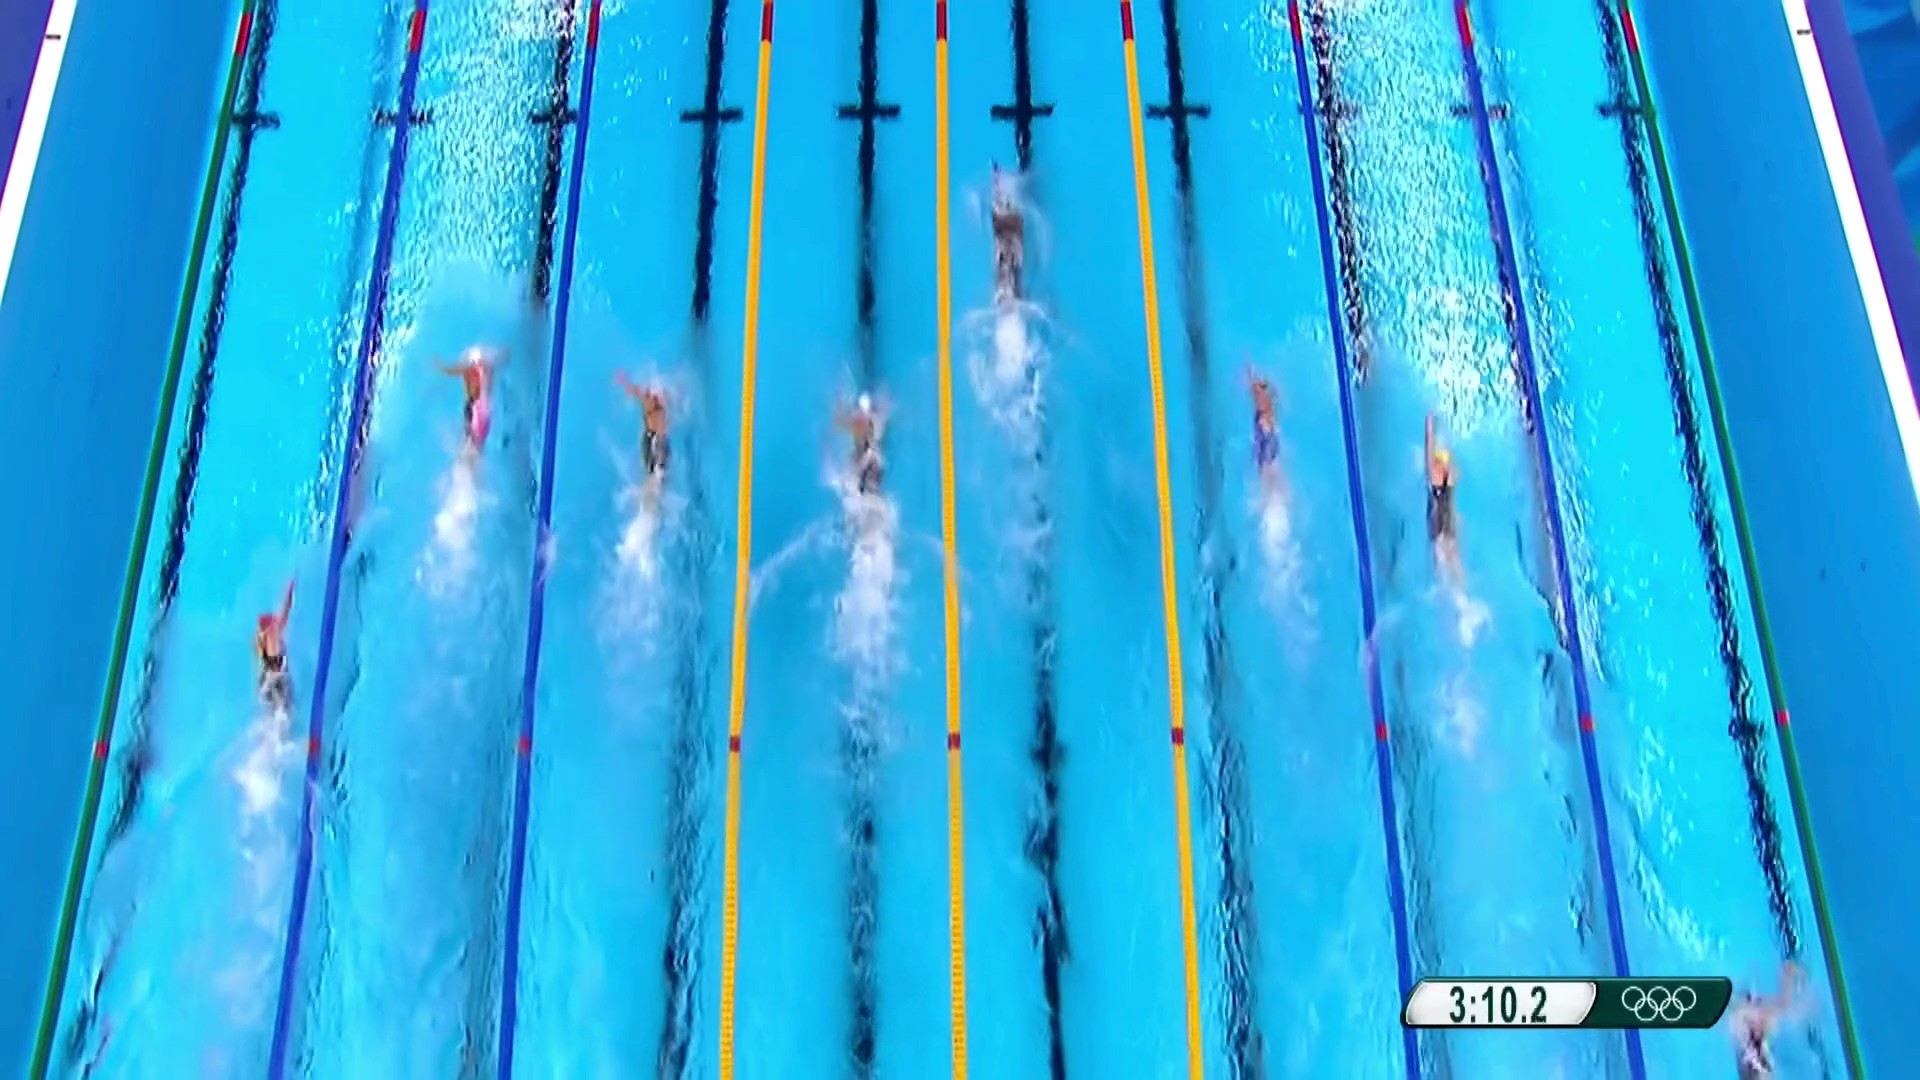

Características de la imagen a tener en cuenta:



*   La piscina tiene un color azulado - cian, el fondo de la piscina es constante y solo tiene 4 casos donde difiere:


    1.   Nadadores
    2.   Burbujas
    3.   Líneas de fondo de la piscina (líneas guía)
    4.   Corcheras (lo que divide los carriles)

*   Las corcheras, en este caso, tienen 3 colores diferentes: Amarillo (las de  la mitad), azul, y verde (las de los bordes). También tienen pedacitos rojos. Eso puede ayudar a la identificación las corcheras y de los carriles. Además siempre son lineas rectas.

*   Las burbujas generan una sensación de color blanco y distorsión.

*   La piscina en general ve que tiene un efecto brillante, o el efecto reflejo del agua. En muchos casos el brillo que muestra un carril puede diferenciar entre lo que es agua y lo que no.

*   Ese contraste del brillo aporta información para identificar las corcheras porque esas mantienen un color y un brillo constante.

*   Las corcheras pueden llegar a parecerse mucho a las líneas guía de la piscina, lo que las llega a diferenciar es la saturación o el color (las del fondo son mucho más oscuras).





### Exploración de espacios de colorimetría

In [10]:
image = cv2.cvtColor(cv2.imread('C:\ProcesamientoImagenesNadadores\data\ejemplos\IS.jpg'), cv2.COLOR_BGR2RGB)
print(image.shape)
image = cv2.resize(image, (512,512))
print(image.shape)

(1080, 1920, 3)
(512, 512, 3)


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\laura\AppData\Local\Temp\ipykernel_29944\1854248871.py:1: SyntaxWarning: invalid escape sequence '\P'
  image = cv2.cvtColor(cv2.imread('C:\ProcesamientoImagenesNadadores\data\ejemplos\IS.jpg'), cv2.COLOR_BGR2RGB)


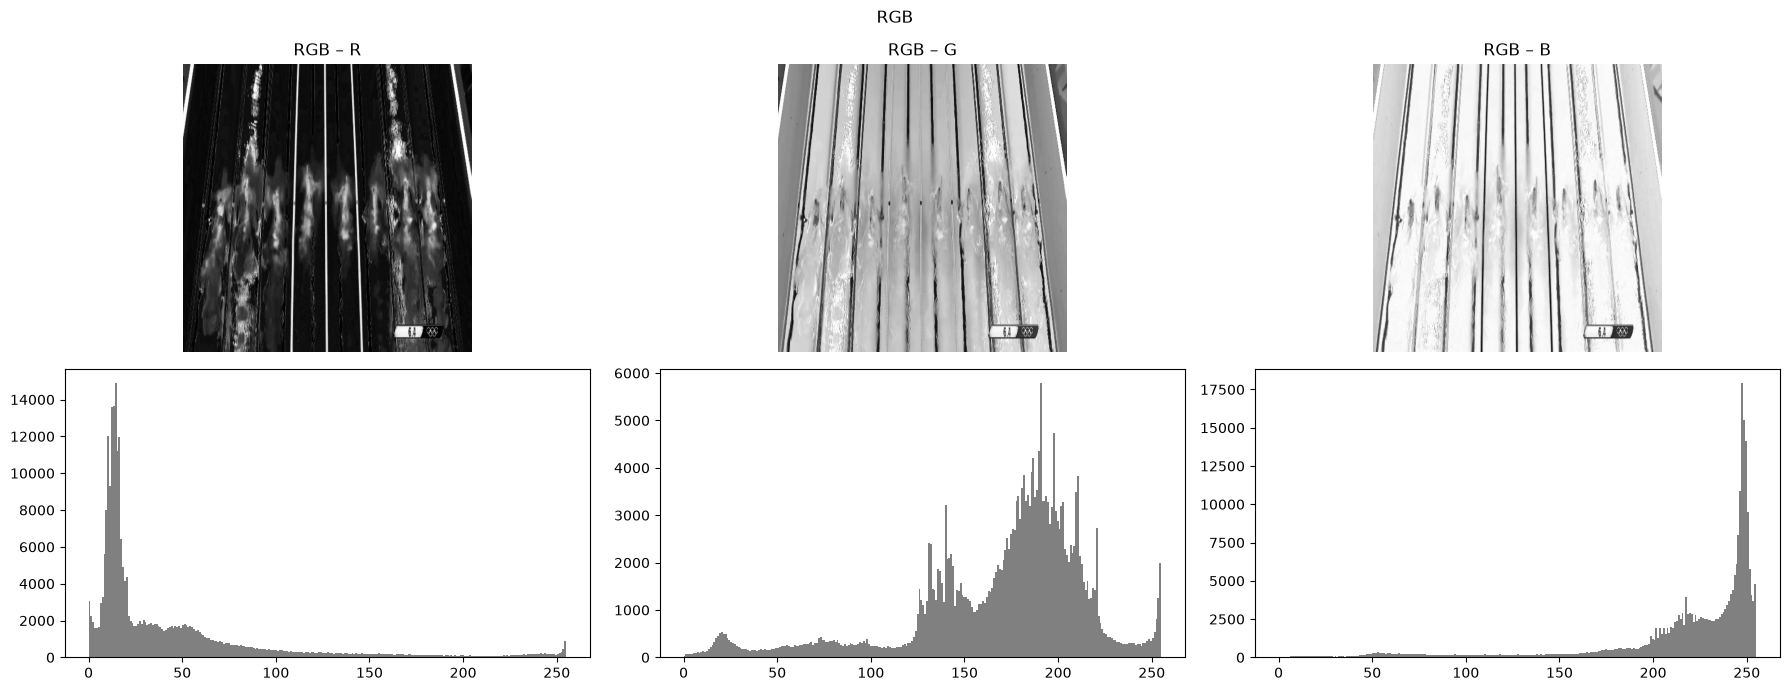

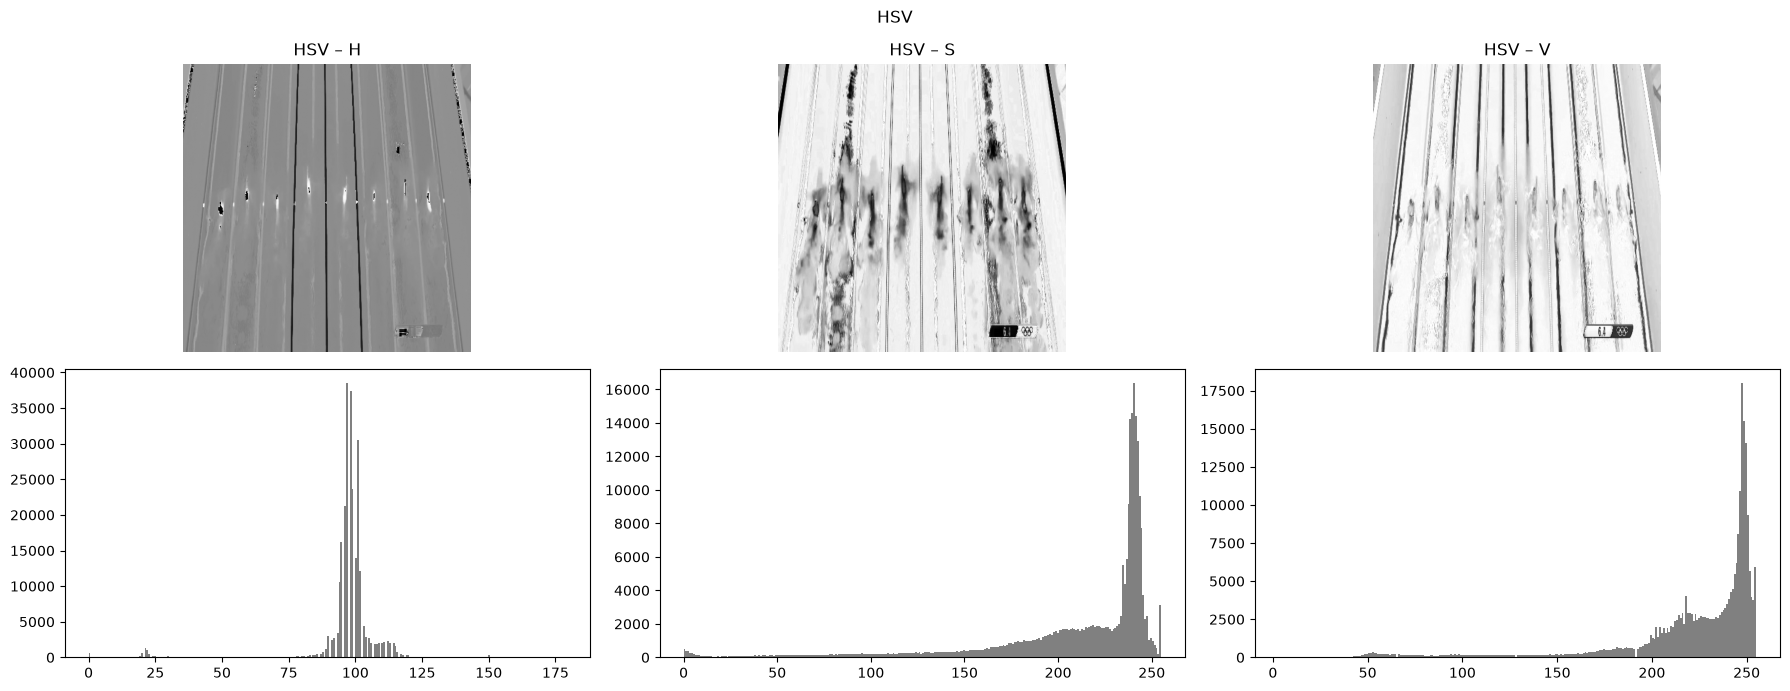

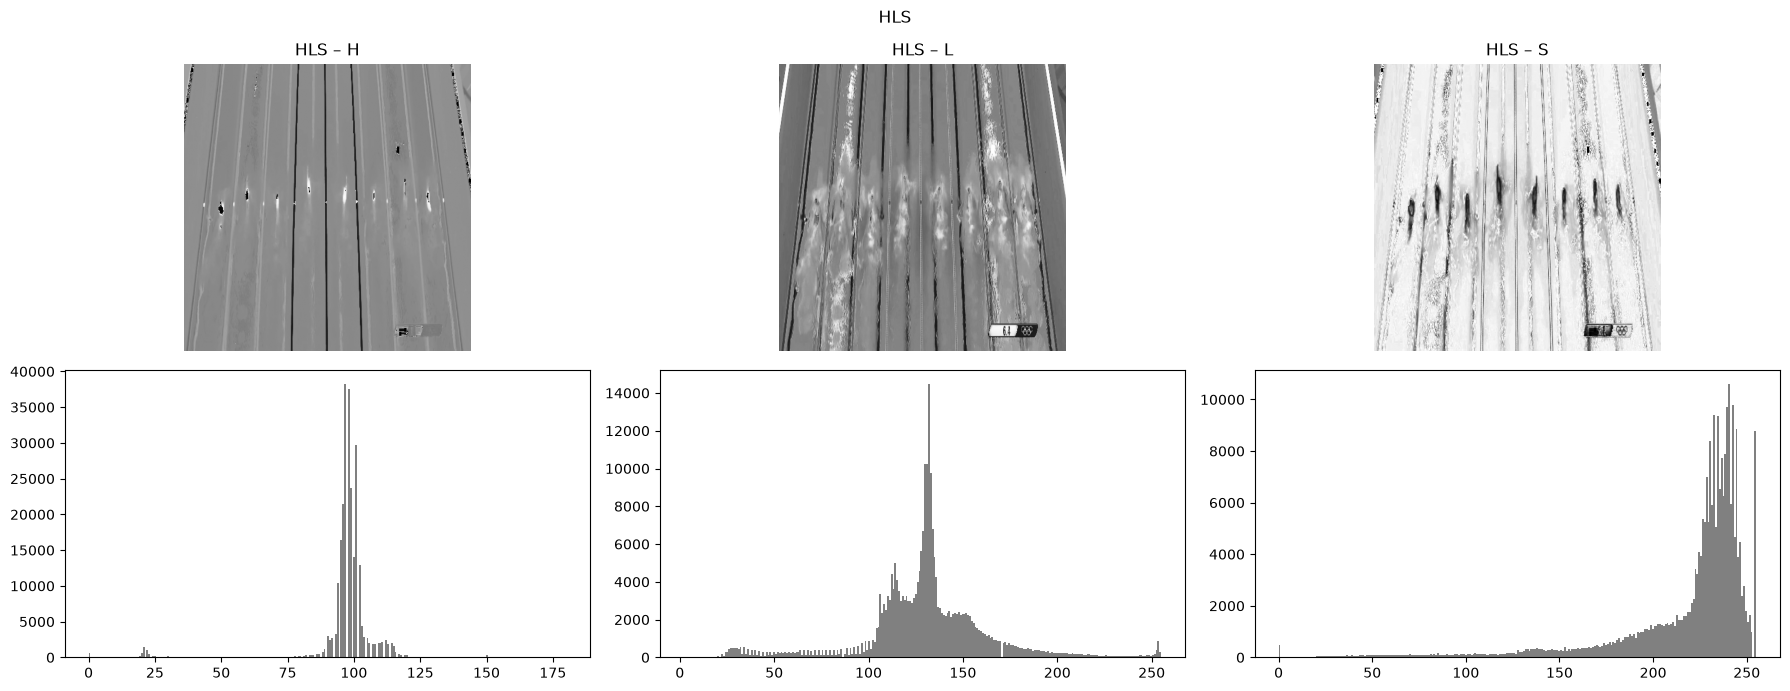

In [11]:
#LAB y YCrCb se ignoran porque no aportan nada.
espacios = {
    'RGB':   (image, ['R', 'G', 'B']),
    'HSV':   (cv2.cvtColor(image, cv2.COLOR_RGB2HSV), ['H', 'S', 'V']),
    'HLS':   (cv2.cvtColor(image, cv2.COLOR_RGB2HLS), ['H', 'L', 'S'])
}

for nombre, (im, canales) in espacios.items():
    fig, ax = plt.subplots(2, 3, figsize=(18, 7))
    for i, c in enumerate(canales):
        ax[0, i].imshow(im[..., i], cmap='gray'); ax[0, i].set_title(f'{nombre} – {c}'); ax[0, i].axis('off')
        ax[1, i].hist(im[..., i].ravel(), bins=256, color='gray')
    plt.suptitle(nombre); plt.tight_layout(); plt.show()

La mayoría de la imagen es piscina, por lo tanto, los píxeles relacionados con la piscina deben ser muy similares (eso implica que el histograma se debe concentrar en una media y no debe tener colas tan alargadas).



*   RGB: en este caso si existen comportamientos inusuales, sobre todo en el espacio de color G (green). Rojo casi no hay en la imagen, por lo que la cola esta a la izquierda. Azul si se presenta mucho por el color del agua/piscina, por lo que tiene cola a la derecha. Pero el verde no se concentra ni a la izquierda ni a la derecha, por lo que no puede hacer una separación 'suficiente' en ese espacio.
*   HSV y HLS:
   

    *   H (tono/color): este es el que más resalta de todos, pues se ve que la curva esta MUY concentrada en el centro, que corresponde al color azul/cyan. Ese tipo de discriminación es la que buscamos. Diferencia muy bien el fondo.
    *   S (HSV): el histograma no es tan centrado y presenta ruido, esto puede ser consecuencia del brillo que refleja la piscina.
    *   S (HLS): a diferencia de S - HSV, este histograma esta más a la derecha. No presenta de forma notoria el reflejo de la piscina. Sin embargo, no logra diferenciar de todo el fondo/las lineas de fondo y las corcheras.
    *   L (HLS): si se ve mucho el efecto del brillo del carril 2 y 8. Eso hace qu eno se diferencie bien el fondo.
    *   V (HSV): El agua queda blanca y uniforme (y tiene un pico en el histograma cercano a 250), de esta forma, lo que es más oscuro resalta más (nadadores, corcheras, líneas guías)

Con esto, el espacio a utilizar sería el HSV:


*   Contra RGB, Lab y YCrCb: en HSV el fondo queda en un solo canal, con un pico estrecho y separado. En RGB está repartido en tres canales, y en Lab y YCrCb el pico es más ancho y el color queda dividido en dos canales.
*   Contra HLS: el tono es el mismo, pero S y V de HSV separan mejor las clases difíciles, es decir, las burbujas y las líneas guía.




### Separación del fondo

Según el histograma de HSV, el tono de la piscina puede encontrarse entre 80 y 110. Se utiliza este valor inicial y a partir de ahí se experimenta.

Además es importante mencionar que los tonos principales en la imagen son:



*   Corchera verde: 87 aprox
*   Piscina agua: 98 aprox
*   Corchera amarilla: 44 aprox
*   Corchera azul: 112
*   Lineas azules guía: 100-110


Esto ya nos da el primer diagnostico: la corchera amarilla se va a segmentar solo por tono. Pero los demás elementos toca hacerle más tratamiento.



In [12]:
hsv = (cv2.cvtColor(image, cv2.COLOR_RGB2HSV))

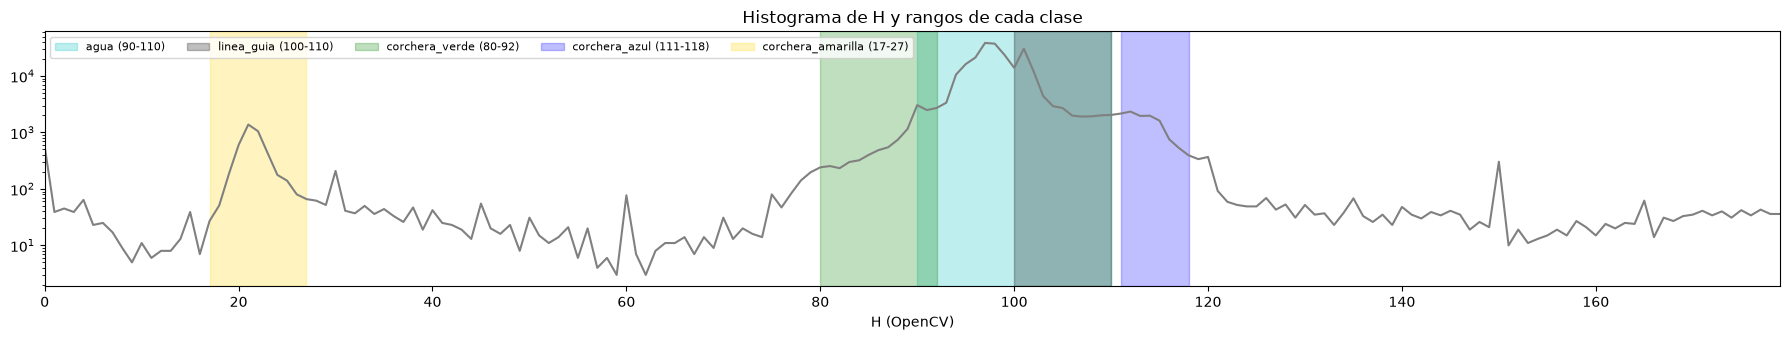

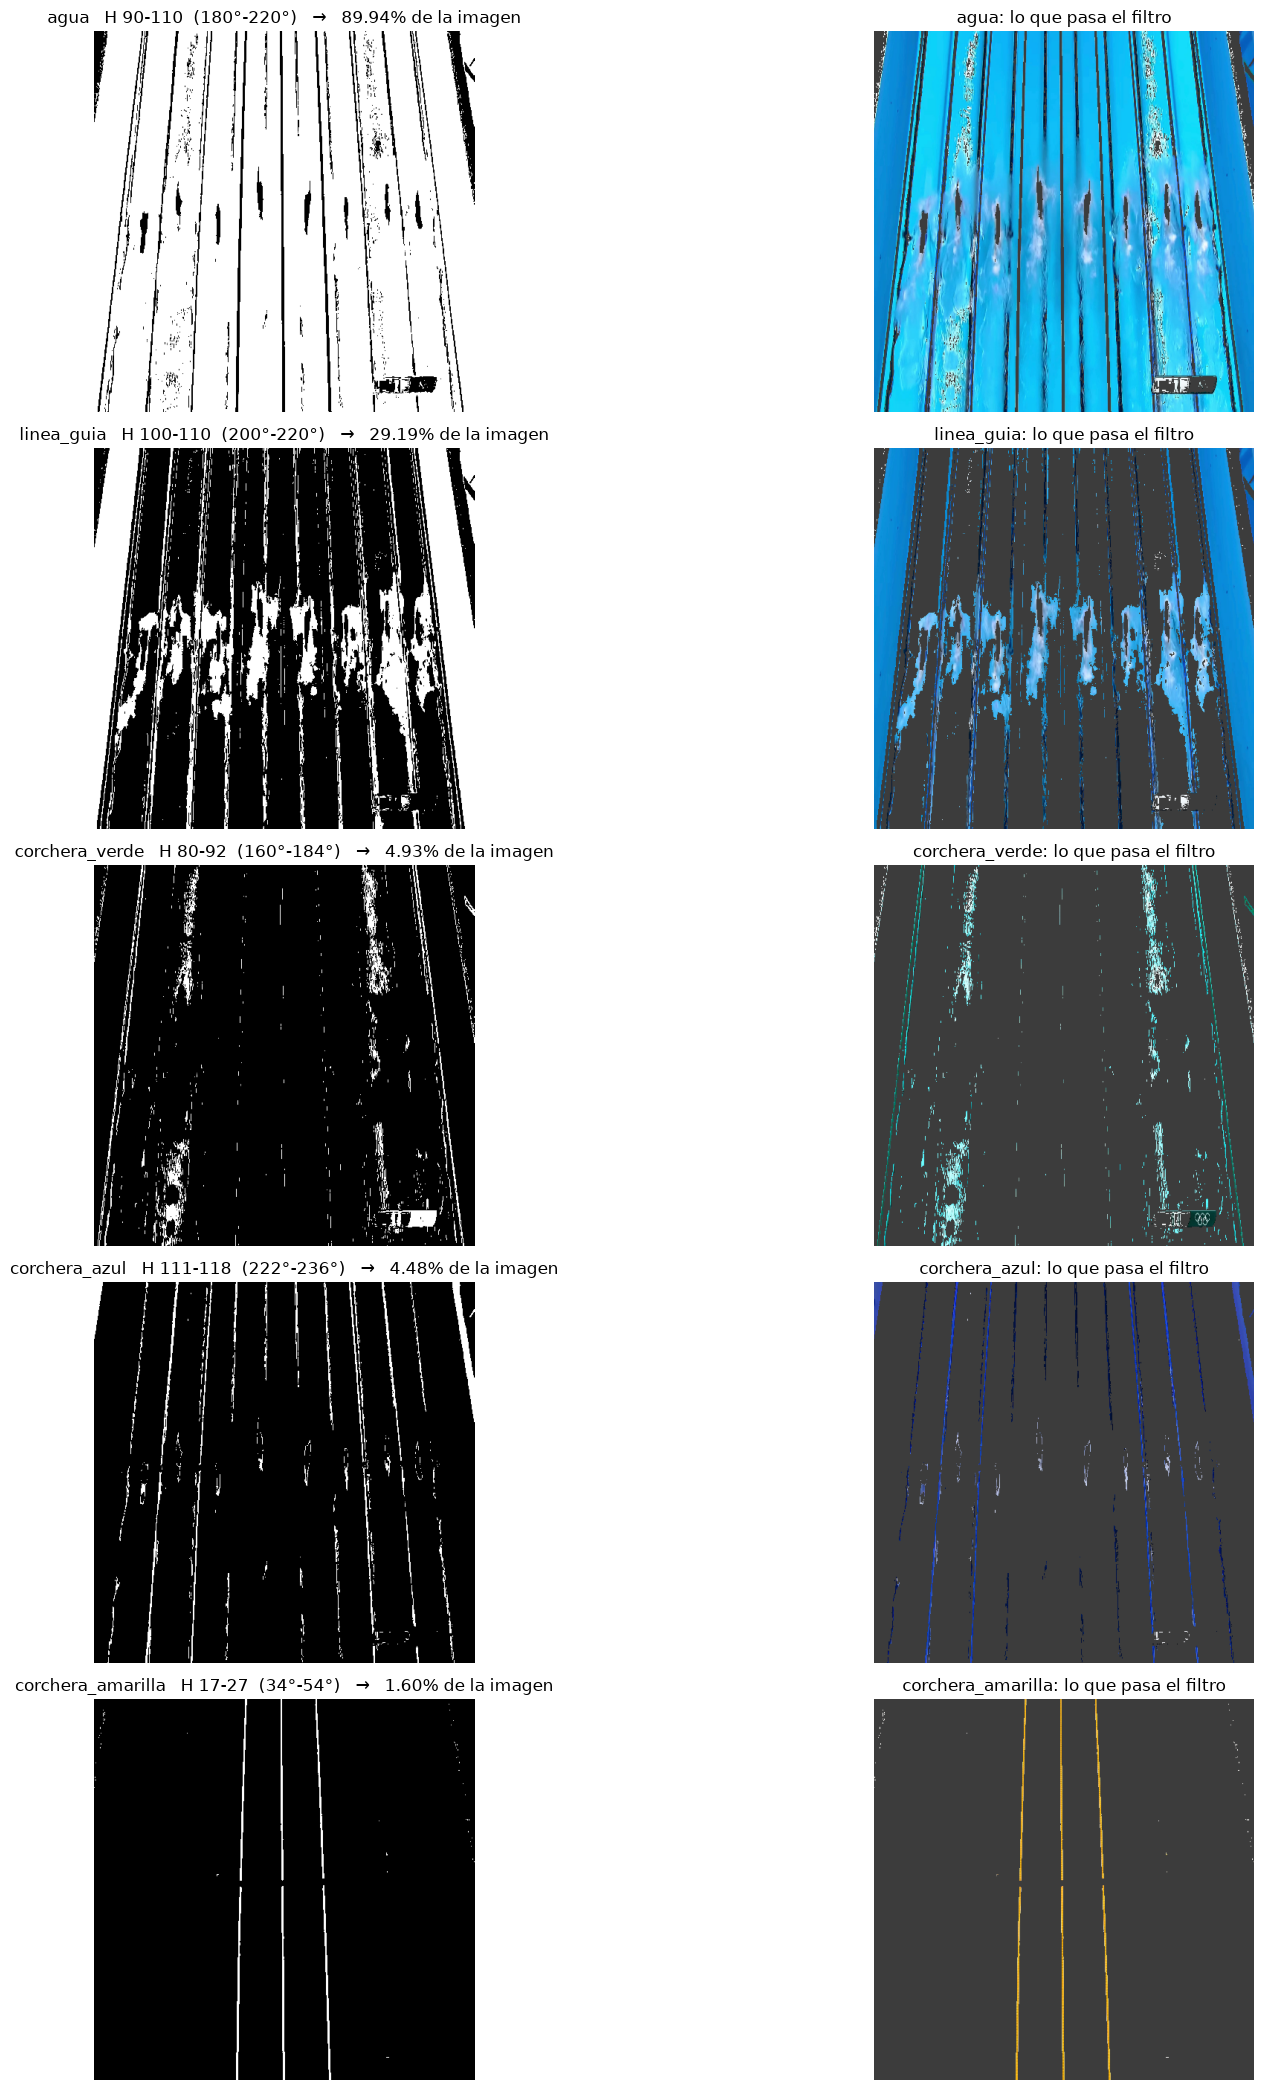

In [ ]:
RANGOS = {
    'agua':              (90, 110),
    'linea_guia':        (100, 110),
    'corchera_verde':    (80, 92),
    'corchera_azul':     (111, 118),
    'corchera_amarilla': (17, 27),
}
COLORES = {'agua': 'c',
           'linea_guia': 'k',
           'corchera_verde': 'g',
           'corchera_azul': 'b',
           'corchera_amarilla': 'gold'
}

H = hsv[..., 0]
mascaras = {c: cv2.inRange(H, h0, h1) for c, (h0, h1) in RANGOS.items()}

# 1) Histograma de H con todos los rangos:
hist_H = cv2.calcHist([hsv], [0], None, [180], [0, 180]).ravel()
fig, ax = plt.subplots(figsize=(18, 3.5))
ax.plot(hist_H, color='gray')
for c, (h0, h1) in RANGOS.items():
    ax.axvspan(h0, h1, alpha=.25, color=COLORES[c], label=f'{c} ({h0}-{h1})')
ax.set_yscale('log'); ax.set_xlim(0, 179); ax.set_xlabel('H (OpenCV)')
ax.legend(fontsize=8, ncol=5, loc='upper left'); ax.set_title('Histograma de H y rangos de cada clase')
plt.tight_layout(); plt.show()

# 2) Todas las máscaras en una sola figura: máscara
fondo_gris = np.full_like(image, 60)             
fig, ax = plt.subplots(len(mascaras), 2, figsize=(20, 4.2 * len(mascaras)))
for fila, (c, m) in zip(ax, mascaras.items()):
    h0, h1 = RANGOS[c]
    fila[0].imshow(m, cmap='gray')
    fila[0].set_title(f'{c}   H {h0}-{h1}  ({h0*2}°-{h1*2}°)   →   {m.mean()/2.55:.2f}% de la imagen')
    fila[1].imshow(np.where(m[..., None] > 0, image, fondo_gris))
    fila[1].set_title(f'{c}: lo que pasa el filtro')
    for a in fila: a.axis('off')
plt.tight_layout(); plt.show()




*   El tono en definitiva es una muy buena opción para separar el fondo de los objetos. Como se ve en la primera imagen, la mascara generada deja pasar la mayoría de píxeles correspondientes al agua y a las líneas de fondo; esto es lo que queremos ignorar.
*   La mascara para la corchera amarilla también es buena tomando en cuenta solo el tono.
*   En las otras mascaras (corcheras azules y verdes), aunque los colores si nos pueden dar idea de como esta la segmentación, no es suficiente porque se presenta mucho ruido. Entonces: para identificar nadadores y corcheras, debemos trabajar con algo más alla del tono.

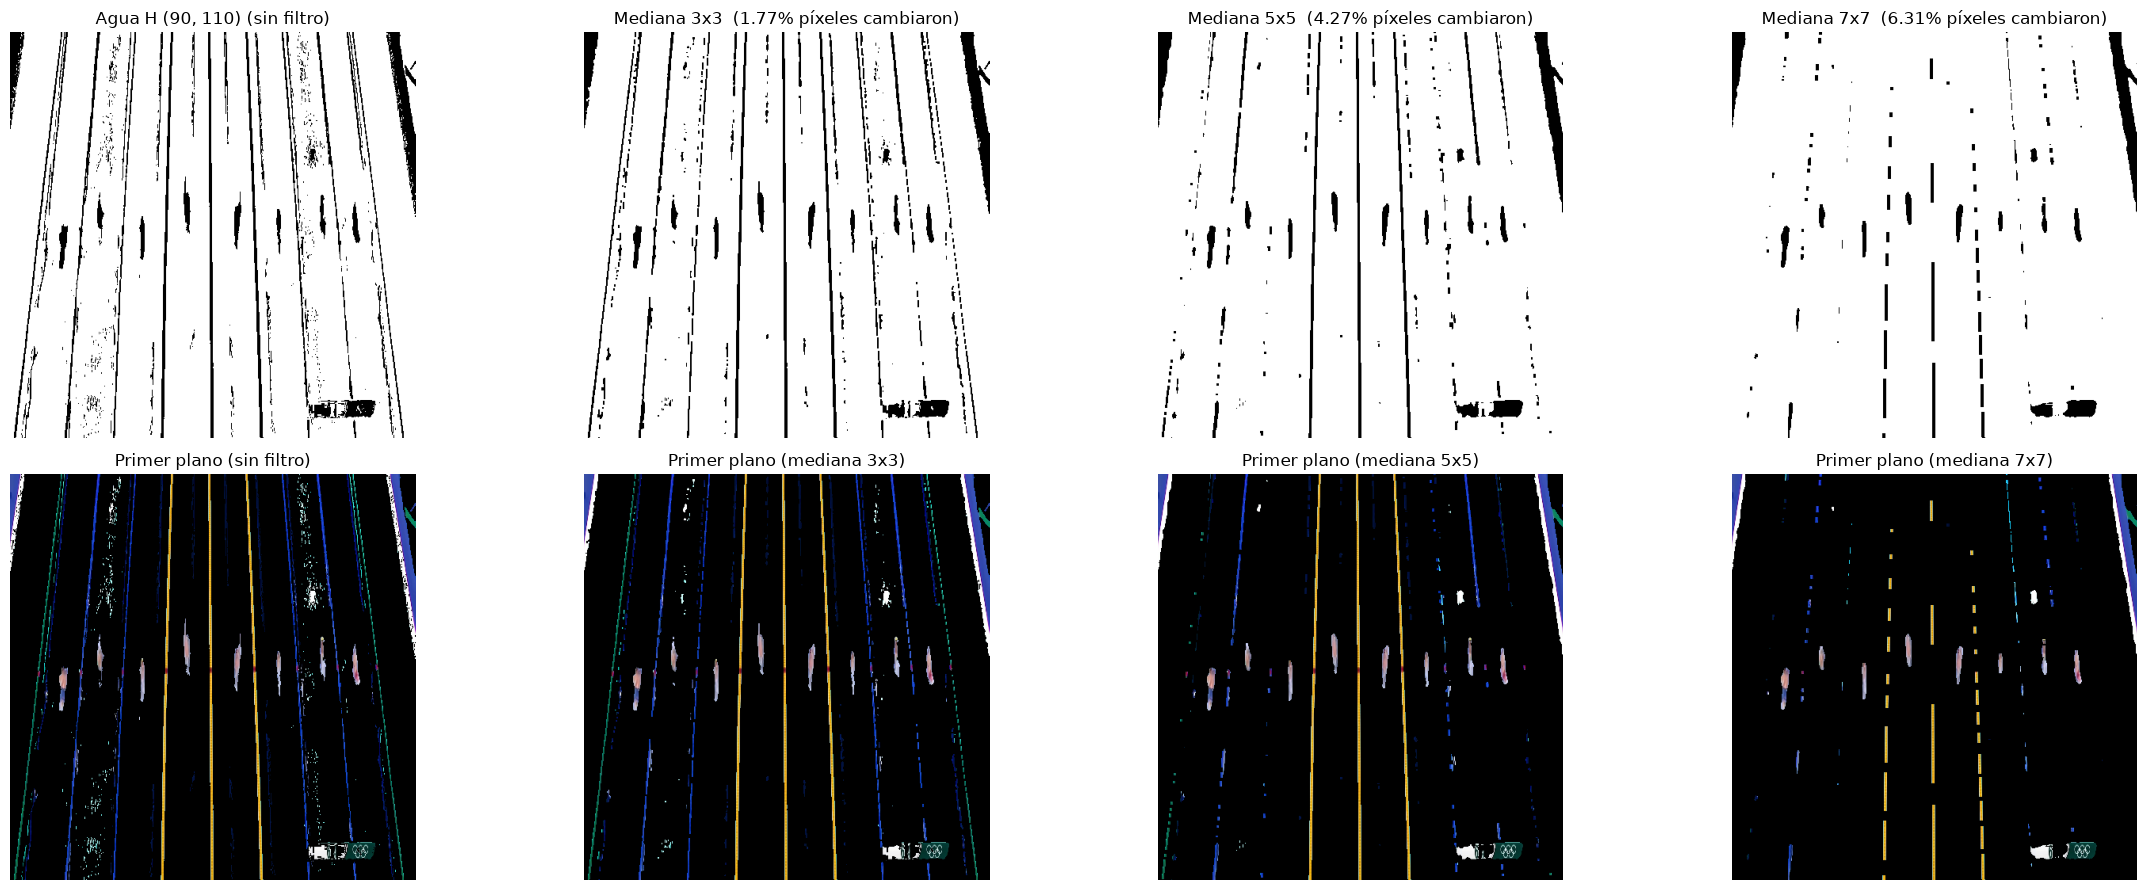

In [ ]:
H_AGUA = (90, 110)                        

agua = cv2.inRange(hsv[..., 0], *H_AGUA)   

tamanos = [3, 5, 7]
agua_filtrada = {k: cv2.medianBlur(agua, k) for k in tamanos}

fig, ax = plt.subplots(2, 4, figsize=(24, 9))
ax[0, 0].imshow(agua, cmap='gray'); ax[0, 0].set_title(f'Agua H {H_AGUA} (sin filtro)')
ax[1, 0].imshow(cv2.bitwise_and(image, image, mask=255 - agua)); ax[1, 0].set_title('Primer plano (sin filtro)')
for i, k in enumerate(tamanos, start=1):
    m = agua_filtrada[k]
    cambiados = (m != agua).mean() * 100
    ax[0, i].imshow(m, cmap='gray'); ax[0, i].set_title(f'Mediana {k}x{k}  ({cambiados:.2f}% píxeles cambiaron)')
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m)); ax[1, i].set_title(f'Primer plano (mediana {k}x{k})')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

Con la máscara de agua fija en H 90-110 se prueba una mediana cuadrada de 3x3, 5x5 y 7x7. La idea es quitar el ruido de burbujas y de brillo sin volver a tocar el tono.

*   La de 3x3 limpia puntos sueltos y casi no mueve el borde del nadador.
*   La de 5x5, y más la de 7x7, cierra más huecos, pero se come al nadador y a las corcheras: la ventana es igual de ancha que de alta y mira para todos lados.

La mediana sola no alcanza. Hace falta un filtro que siga la dirección de los carriles en vez de suavizar en todas las direcciones. Eso se prueba en la celda siguiente.

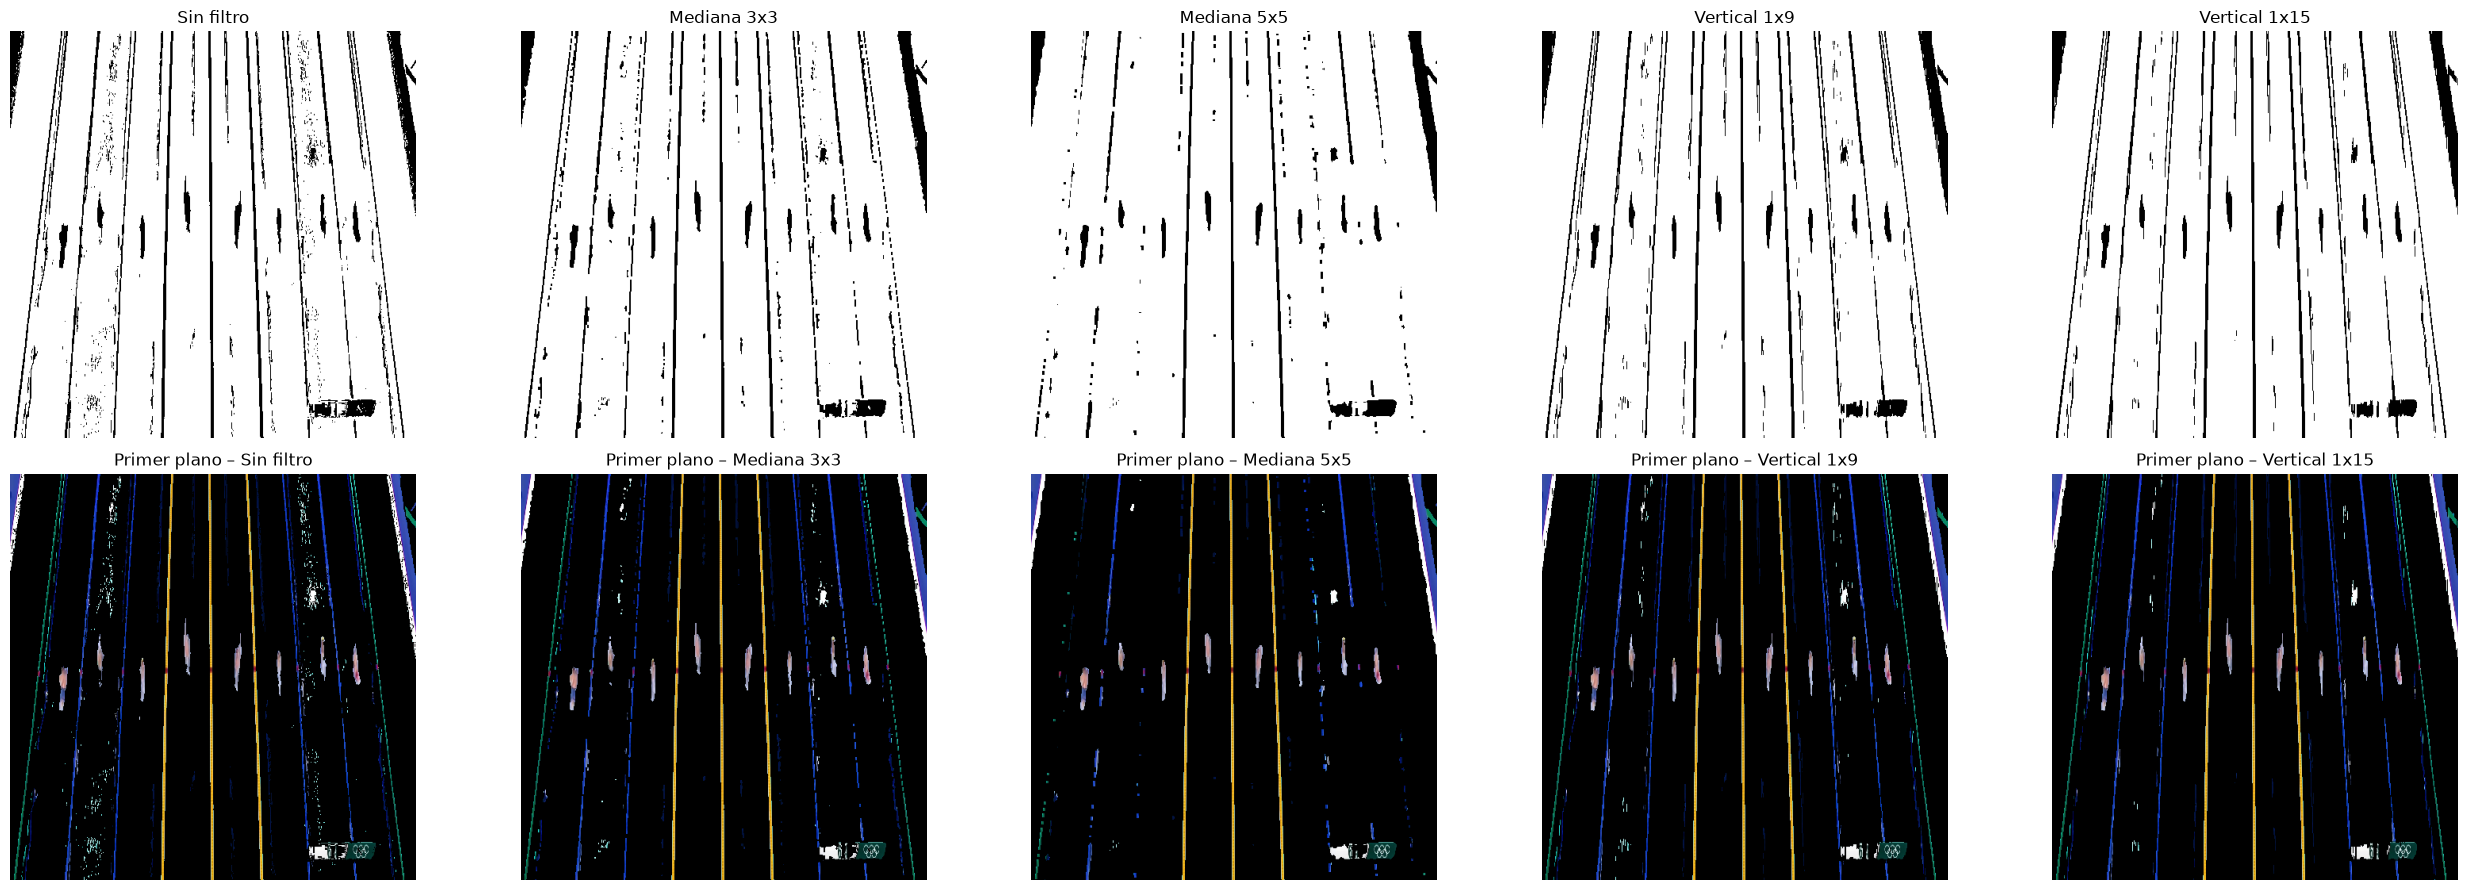

In [31]:
agua = cv2.inRange(hsv[..., 0], 90, 110)

def votacion(mascara, ancho, alto):
    """Promedio en una ventana ancho x alto y umbral 0.5 = votación de mayoría (como la mediana)."""
    return ((cv2.blur(mascara, (ancho, alto)) > 127) * 255).astype(np.uint8)

versiones = {
    'Sin filtro':          agua,
    'Mediana 3x3':         cv2.medianBlur(agua, 3),
    'Mediana 5x5':         cv2.medianBlur(agua, 5),
    'Vertical 1x9':        votacion(agua, 1, 9),
    'Vertical 1x15':       votacion(agua, 1, 15),
}

fig, ax = plt.subplots(2, len(versiones), figsize=(26, 9))
for i, (nombre, m) in enumerate(versiones.items()):
    ax[0, i].imshow(m, cmap='gray'); ax[0, i].set_title(nombre)
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m)); ax[1, i].set_title(f'Primer plano – {nombre}')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

La mediana cuadrada mira para todos lados, así que quita puntos sueltos pero también se come el borde del nadador y de las corcheras. La ventana vertical solo vota hacia arriba y hacia abajo: un píxel queda como agua si la mayoría de esa columna corta también es agua.

*   La mediana 3x3 cambia poco. La 5x5 ya suaviza de más y desdibuja el primer plano.
*   La ventana 1x9 todavía deja huecos de burbuja y de brillo. La 1x15 los cierra mejor sin borrar al nadador.

Por eso se sigue con la votación vertical 1x15. La mediana cuadrada queda solo como un filtro fino, no como el filtro principal.

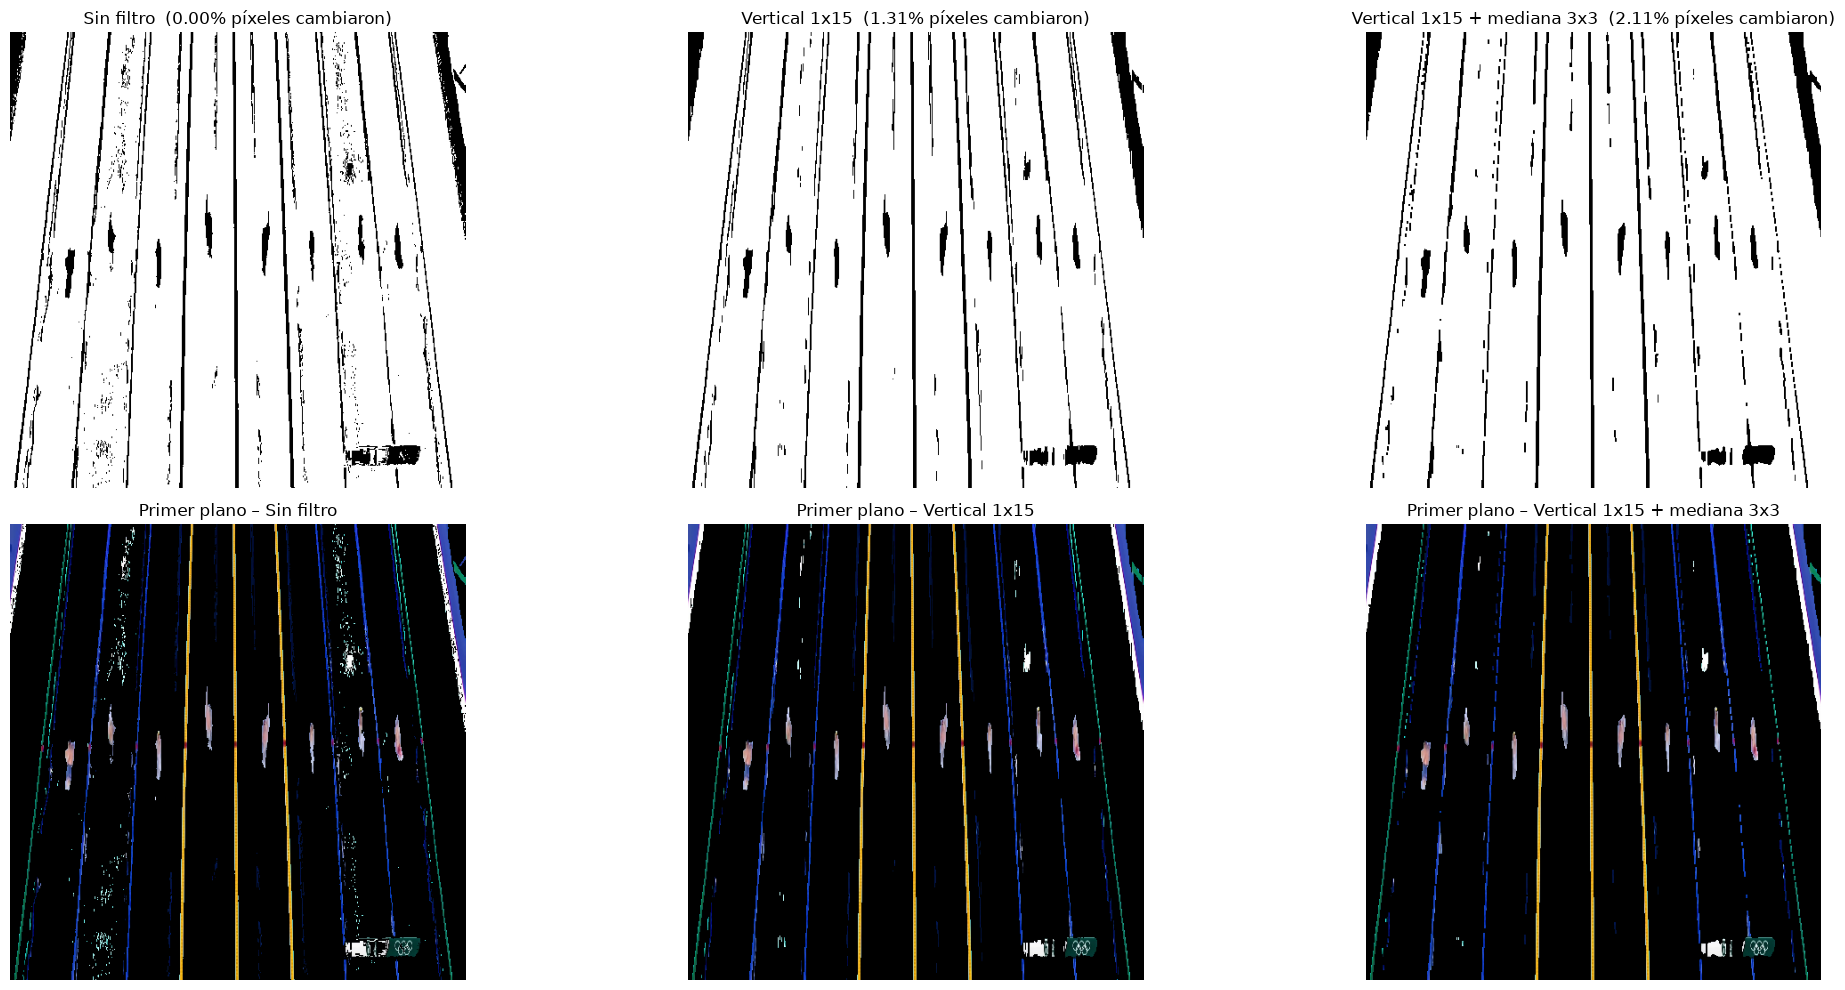

In [32]:
agua = cv2.inRange(hsv[..., 0], 90, 110)

versiones = {
    'Sin filtro':                  agua,
    'Vertical 1x15':               votacion(agua, 1, 15),
    'Vertical 1x15 + mediana 3x3': cv2.medianBlur(votacion(agua, 1, 15), 3),
}

fig, ax = plt.subplots(2, len(versiones), figsize=(22, 10))
for i, (nombre, m) in enumerate(versiones.items()):
    cambiados = (m != agua).mean() * 100
    ax[0, i].imshow(m, cmap='gray')
    ax[0, i].set_title(f'{nombre}  ({cambiados:.2f}% píxeles cambiaron)')
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m))
    ax[1, i].set_title(f'Primer plano – {nombre}')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

La ventana 1x15 no ve a los vecinos de los lados, así que puede quedar ruido en horizontal. Una mediana 3x3 después de la votación quita esos puntos sin deshacer lo que el filtro vertical ya cerró.

*   La vertical 1x15 sola ya separa la mayor parte del agua.
*   Sumarle la mediana 3x3 cambia pocos píxeles y deja la máscara más limpia.
*   Esa combinación es la que se usa de aquí en adelante.

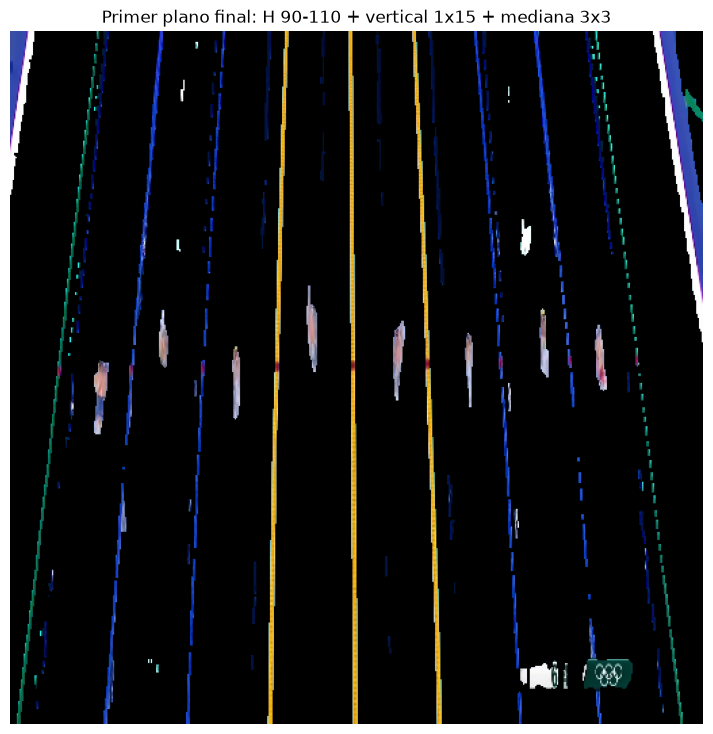

In [33]:
agua = cv2.inRange(hsv[..., 0], 90, 110)
combinado = cv2.medianBlur(votacion(agua, 1, 15), 3)   # vertical 1x15 + mediana 3x3

primer_plano = cv2.bitwise_and(image, image, mask=255 - combinado)

plt.figure(figsize=(16, 9))
plt.imshow(primer_plano)
plt.title('Primer plano final: H 90-110 + vertical 1x15 + mediana 3x3')
plt.axis('off')
plt.show()

Máscara de agua de la vista superior: tono H entre 90 y 110, votación vertical 1x15 y mediana 3x3.

Lo negro es agua (lo que se ignora). Lo que se ve en color es lo que no pasó ese filtro: nadadores, corcheras y lo que el tono no clasificó como piscina.